In [130]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума

In [131]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

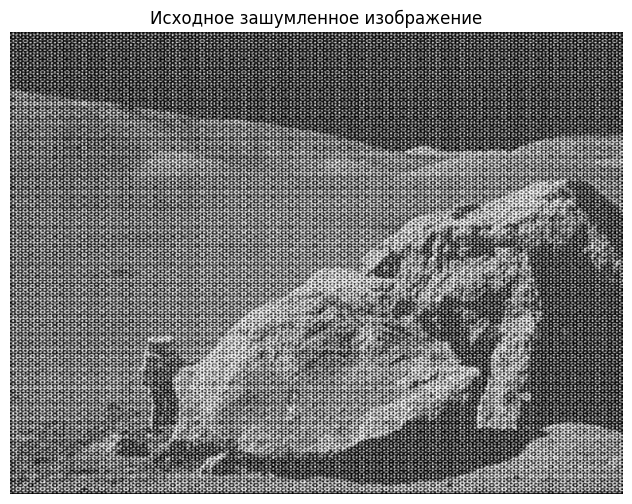

In [132]:
image = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap='gray')
plt.title('Исходное зашумленное изображение')
plt.axis('off')
plt.show()

### 1. Реализуйте высокочастотную фильтрацию на основе ядра Гаусса

In [133]:
def gaussian_highpass_filter(image, sigma=30):
    # Прямое преобразование Фурье
    dft = cv.dft(np.float32(image), flags=cv.DFT_COMPLEX_OUTPUT)  
    dft_shift = np.fft.fftshift(dft)  
    
    # Расчет спектра до фильтрации
    magnitude_spectrum_before = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
    
    # Создание Гауссова высокочастотного фильтра
    rows, cols = image.shape
    
    # Создание координатной сетки
    x, y = np.meshgrid(np.arange(cols), np.arange(rows))
    center_x, center_y = cols // 2, rows // 2
    
    # Расчет Гауссова низкочастотного фильтра
    gauss_lowpass = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * sigma**2))
    
    # Преобразование в высокочастотный фильтр
    gauss_highpass = 1 - gauss_lowpass
    
    # Применение фильтра к спектру
    dft_shift_filtered = dft_shift * gauss_highpass[:, :, np.newaxis]
    
    # Расчет спектра после фильтрации
    magnitude_spectrum_after = 20 * np.log(cv.magnitude(dft_shift_filtered[:,:,0], dft_shift_filtered[:,:,1]) + 1)
    
    # Обратное преобразование Фурье
    f_ishift = np.fft.ifftshift(dft_shift_filtered)
    img_back = cv.idft(f_ishift)
    filtered_image = cv.magnitude(img_back[:,:,0], img_back[:,:,1])
    
    return filtered_image, magnitude_spectrum_before, magnitude_spectrum_after, gauss_highpass

In [134]:
img_highpass, magnitude_before, magnitude_after, gauss_filter = gaussian_highpass_filter(image, sigma=25)

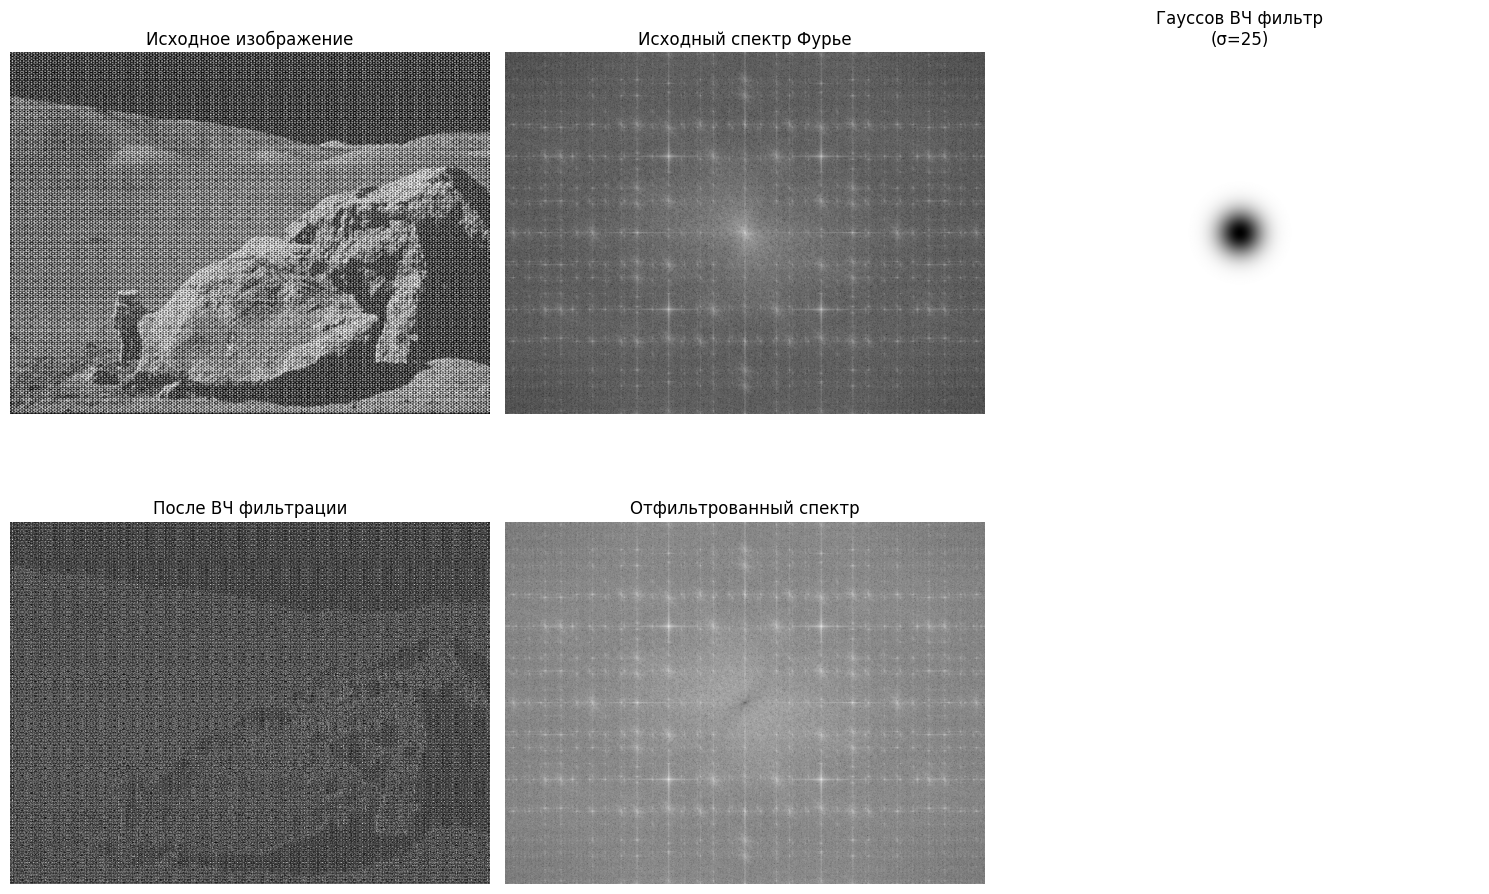

In [135]:
# Визуализация результатов высокочастотной фильтрации
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_before, cmap='gray')
plt.title('Исходный спектр Фурье')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gauss_filter, cmap='gray')
plt.title('Гауссов ВЧ фильтр\n(σ=25)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_highpass, cmap='gray')
plt.title('После ВЧ фильтрации')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(magnitude_after, cmap='gray')
plt.title('Отфильтрованный спектр')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Реализуйте удаление периодического шума

In [136]:
# Новое преобразование Фурье для исходного изображения
dft_clean = cv.dft(np.float32(image), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift_clean = np.fft.fftshift(dft_clean)

# Расчет спектра для анализа шума
magnitude_spectrum_clean = 20 * np.log(cv.magnitude(dft_shift_clean[:,:,0], dft_shift_clean[:,:,1]) + 1)

# Поиск шумовых компонент в спектре
local_maxima = peak_local_max(magnitude_spectrum_clean, 
                             min_distance=20, 
                             threshold_abs=180)

print(f"Обнаружено пиков: {len(local_maxima)}")

# Создание маски для подавления шума
rows, cols = image.shape
mask = np.ones((rows, cols, 2), dtype=np.float32)
center_x, center_y = rows // 2, cols // 2

# Подавление обнаруженных шумовых компонент
noise_peaks_removed = 0
for peak in local_maxima:
    y, x = peak
    # Игнорируем центральную область (низкие частоты)
    distance = np.sqrt((x - center_y)**2 + (y - center_x)**2)
    if distance > 40:  
        cv.circle(mask, (x, y), 5, (0, 0), -1)
        noise_peaks_removed += 1

print(f"Подавлено шумовых компонент: {noise_peaks_removed}")

# Применение маски к спектру
dft_shift_filtered_noise = dft_shift_clean * mask

# Расчет отфильтрованного спектра
magnitude_spectrum_noise_removed = 20 * np.log(cv.magnitude(dft_shift_filtered_noise[:,:,0], 
                                                            dft_shift_filtered_noise[:,:,1]) + 1)

# Обратное преобразование
f_ishift_noise = np.fft.ifftshift(dft_shift_filtered_noise)
img_noise_removed = cv.idft(f_ishift_noise)
img_noise_removed = cv.magnitude(img_noise_removed[:,:,0], img_noise_removed[:,:,1])

Обнаружено пиков: 328
Подавлено шумовых компонент: 327


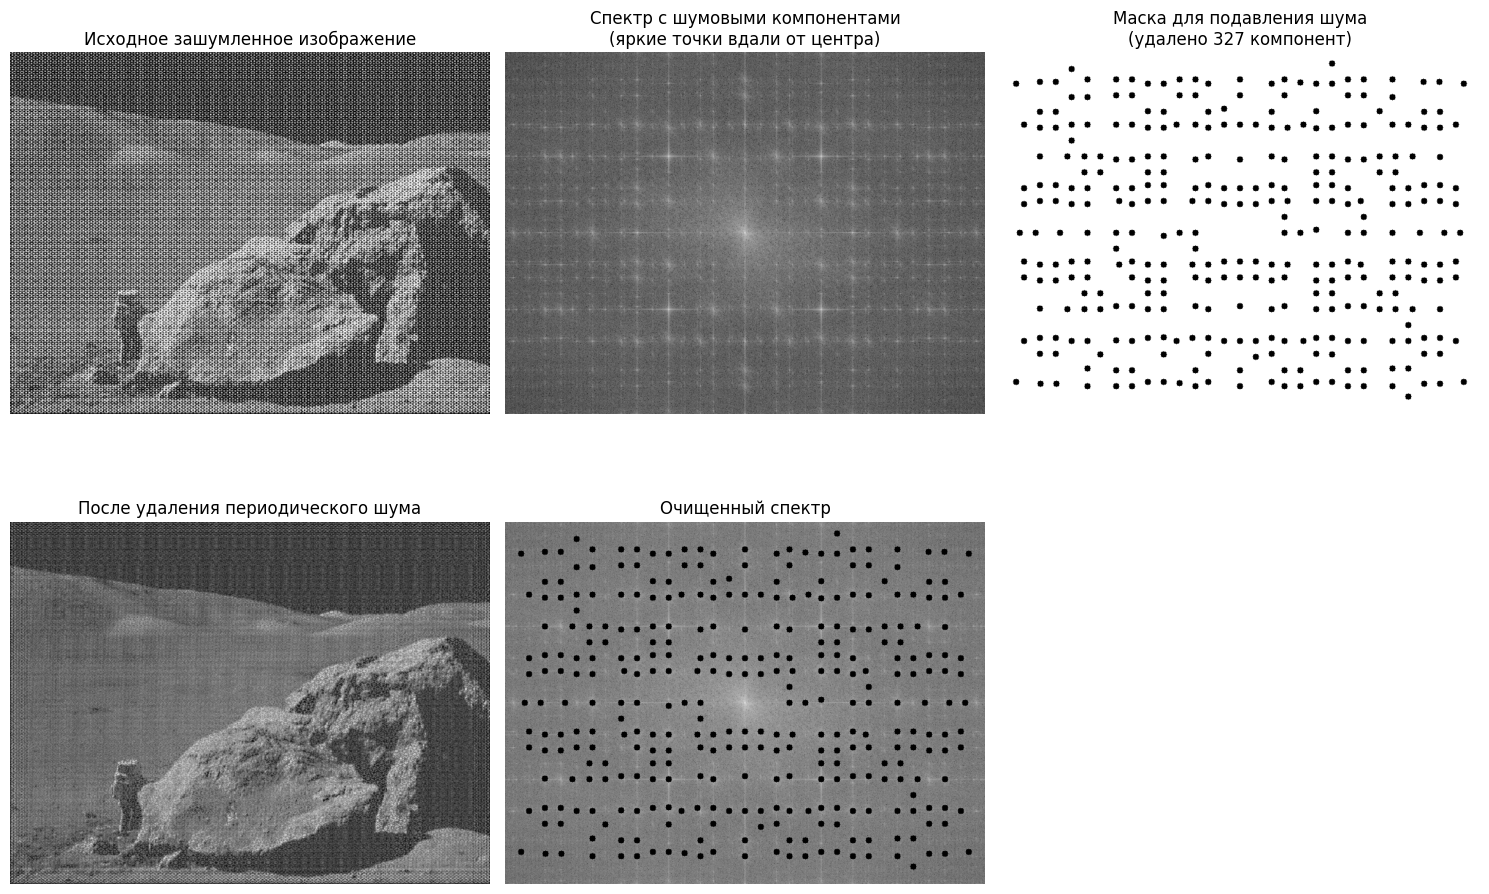

In [137]:
# Визуализация результатов удаления шума
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное зашумленное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum_clean, cmap='gray')
plt.title('Спектр с шумовыми компонентами\n(яркие точки вдали от центра)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(mask[:,:,0], cmap='gray')
plt.title(f'Маска для подавления шума\n(удалено {noise_peaks_removed} компонент)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_noise_removed, cmap='gray')
plt.title('После удаления периодического шума')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(magnitude_spectrum_noise_removed, cmap='gray')
plt.title('Очищенный спектр')
plt.axis('off')

plt.tight_layout()
plt.show()

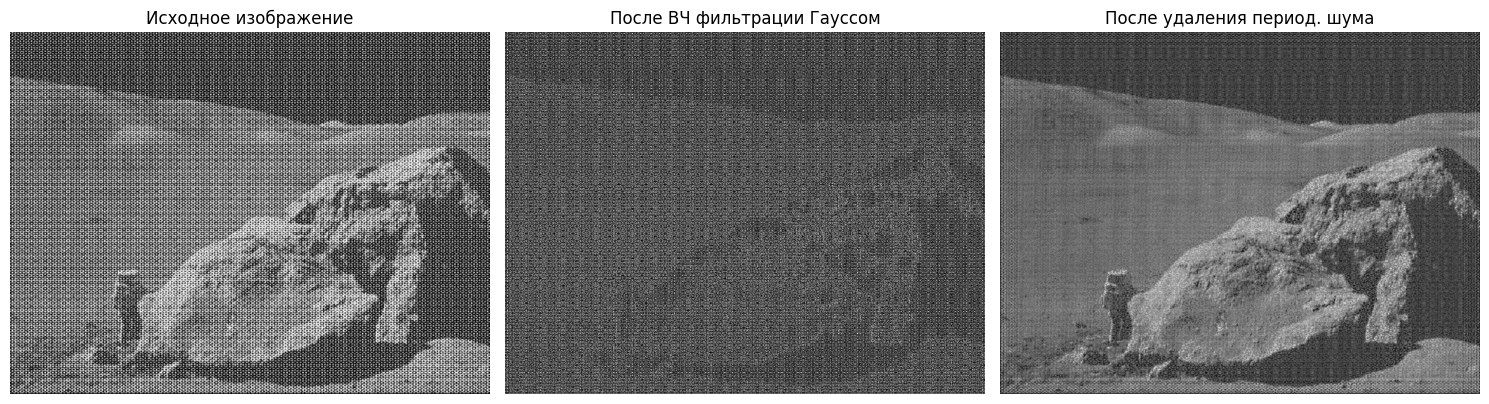

In [138]:
# Итог

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_highpass, cmap='gray')
plt.title('После ВЧ фильтрации Гауссом')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_noise_removed, cmap='gray')
plt.title('После удаления период. шума')
plt.axis('off')

plt.tight_layout()
plt.show()